# Semantic news search & clustering

Can a pretrained sentence-embedding model find the structure in news text **without ever seeing the category labels**, and can the same embeddings power a search engine that matches on *meaning* rather than keywords?

This notebook answers both questions on a 3,000-article sample of [AG News](https://huggingface.co/datasets/fancyzhx/ag_news) (World / Sports / Business / Sci-Tech) using the `all-MiniLM-L6-v2` sentence-transformer.

1. **Data**: sample and inspect AG News
2. **Embeddings**: encode every article as a 384-dimensional vector
3. **Clustering**: KMeans on the embeddings, compared against the true categories (ARI)
4. **Semantic search**: cosine-similarity retrieval with natural-language queries

The same logic is available as a reusable package in `src/newssearch/` (see the README); this notebook is the exploratory walkthrough.

In [1]:
!pip install -q sentence-transformers umap-learn datasets

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from umap import UMAP

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data

A random sample of 3,000 training articles, seeded for reproducibility. The classes come out roughly balanced. Each `text` is a headline followed by a short blurb.

In [4]:
dataset = load_dataset("fancyzhx/ag_news")

LABEL_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

N_SAMPLES = 3000

df = dataset["train"].shuffle(seed = RANDOM_STATE).select(range(N_SAMPLES)).to_pandas()
df["label_name"] = df["label"].map(LABEL_NAMES)

print(df.shape)
print(df["label_name"].value_counts())
df.head()

(3000, 3)
label_name
Sci/Tech    796
World       771
Sports      742
Business    691
Name: count, dtype: int64


,text,label,label_name
0,Bangladesh paralysed by strikes Opposition act...,0,World
1,Desiring Stability Redskins coach Joe Gibbs ex...,1,Sports
2,Will Putin #39;s Power Play Make Russia Safer?...,0,World
3,U2 pitches for Apple New iTunes ads airing dur...,3,Sci/Tech
4,S African TV in beheading blunder Public broad...,0,World


## 2. Embeddings

`all-MiniLM-L6-v2` maps each article to a 384-dimensional vector so that texts with similar meaning land close together. It is a small, fast model that runs comfortably on a CPU.

In [5]:
model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df["text"].tolist()
embeddings = model.encode(texts, show_progress_bar = True, batch_size = 64)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Embeddings shape: (3000, 384)


## 3. Unsupervised clustering

Two separate steps with different jobs:

- **KMeans (k=4)** runs on the full 384-dimensional embeddings, ignoring the labels.
- **UMAP** squashes the embeddings to 2D **for plotting only**. Clustering in the 2D projection would throw away information.

The **Adjusted Rand Index (ARI)** measures how well the clusters agree with the true categories: 0 is chance-level agreement and 1 is a perfect match. It doesn't care how the clusters happen to be numbered.

In [6]:
# 2D projection, for plotting only
reducer = UMAP(n_components=2, random_state=RANDOM_STATE)
embeddings_2d = reducer.fit_transform(embeddings)

# Clustering on the full-dimensional embeddings
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(embeddings)

ari = adjusted_rand_score(df["label"], clusters)
print(f"Adjusted Rand Index (cluster agreement with true categories): {ari:.3f}")

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Adjusted Rand Index (cluster agreement with true categories): 0.636


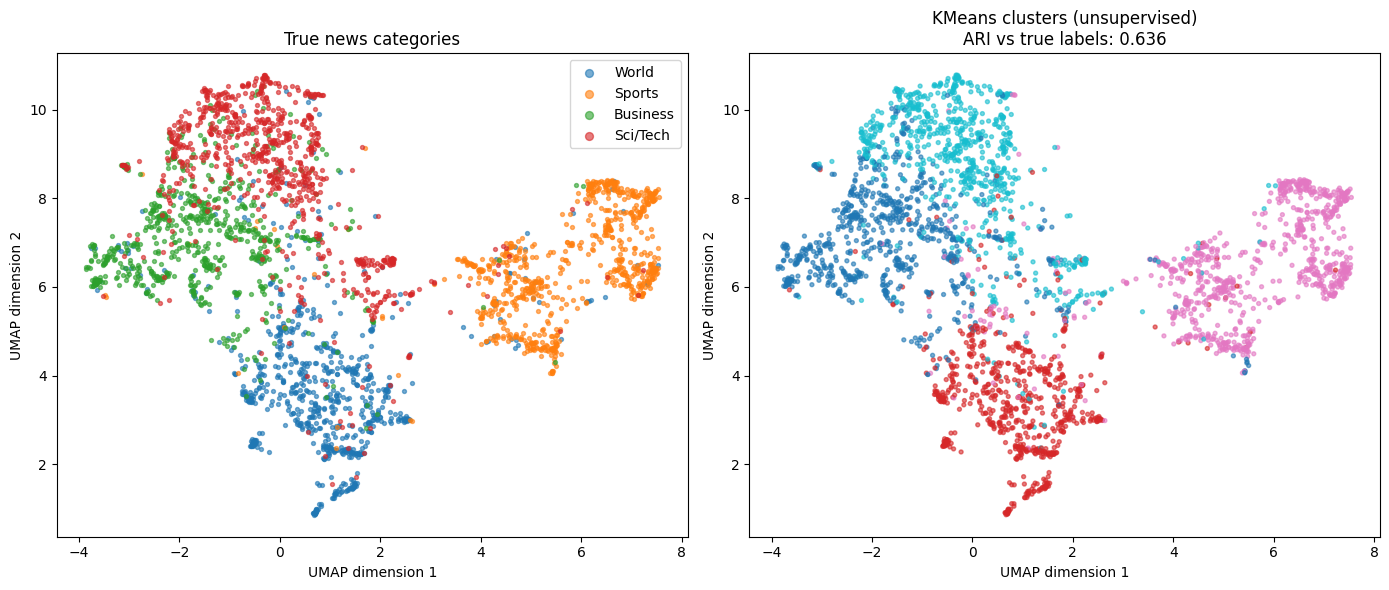

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label_val, label_name in LABEL_NAMES.items():
    mask = df["label"] == label_val
    axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], s=8, alpha=0.6, label=label_name)
axes[0].set_title("True news categories")
axes[0].legend(markerscale=2)

scatter = axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=8, alpha=0.6, c=clusters, cmap="tab10")
axes[1].set_title(f"KMeans clusters (unsupervised)\nARI vs true labels: {ari:.3f}")

for ax in axes:
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")

plt.tight_layout()
plt.savefig("cluster_comparison.png", dpi=150)
plt.show()

**Reading the plot.** With no supervision, KMeans reaches an ARI of about 0.64. Sports forms its own island. World sits apart from the rest. Business and Sci/Tech overlap heavily, which is where most disagreement between clusters and labels lives. That is unsurprising, since technology-company earnings and deals are legitimately both. Some of the "errors" also come from the dataset's labels themselves, which are noisy.

## 4. Semantic search

Embed the query with the same model and rank all articles by cosine similarity. Because the match is on meaning rather than exact keywords, a query doesn't need to use the same wording as the article it retrieves.

In [8]:
def semantic_search(query, texts, embeddings, model, top_k=5):
    query_embedding = model.encode([query])
    sims = cosine_similarity(query_embedding, embeddings)[0]
    top_idx = np.argsort(-sims)[:top_k]
    return [(texts[i], sims[i], df.iloc[i]["label_name"]) for i in top_idx]


def print_results(query, results):
    print(f'\nQuery: "{query}"')
    print("-" * 60)
    for text, score, category in results:
        print(f"[{score:.3f}] ({category}) {text}")

In [9]:
example_queries = [
    "a company's stock price falling after a bad earnings report",
    "an athlete winning a gold medal",
    "a new breakthrough in artificial intelligence",
    "tensions between two countries over a border dispute",
]

for q in example_queries:
    results = semantic_search(q, texts, embeddings, model, top_k=3)
    print_results(q, results)


Query: "a company's stock price falling after a bad earnings report"
------------------------------------------------------------
[0.587] (World) Stocks Slip on GM Earnings, Higher Oil NEW YORK - Investors sent stocks falling sharply Thursday as crude oil prices surged near \$55 per barrel and General Motors Corp. issued a disappointing earnings report...
[0.574] (World) Stocks Slump on Gloomy Economic Forecasts NEW YORK - Stocks sagged Wednesday after Coca-Cola Co. and several other companies issued gloomy forecasts, and a lower-than-expected reading on industrial production for August threw the nation's broader economic outlook into question...
[0.557] (Business) TJX Cos. Earnings Fall 4 Percent TJX Cos. Inc. #39;s second-quarter earnings fell 4 percent, reflecting higher markdowns on merchandise due to softer sales trends. 

Query: "an athlete winning a gold medal"
------------------------------------------------------------
[0.534] (Sports) Guerrouj Captures Gold in the 5,000 Hich

**What worked and what didn't.** The earnings and gold-medal queries return on-topic stories at solid similarity scores (about 0.5 to 0.6). The AI query is weak: top scores are only ~0.3 and the results are loosely related tech stories, because AG News dates from 2004 and contains essentially no modern AI coverage. Retrieval can only surface what is in the corpus, and a low top score is the signal that nothing good matched.

## Try your own query

Edit the query and re-run. Scores well below ~0.3 usually mean the corpus has nothing relevant.

In [ ]:
your_query = "oil prices surge as investors worry about the economy"  # edit this and re-run
results = semantic_search(your_query, texts, embeddings, model, top_k=5)
print_results(your_query, results)